# Machine Learning

## Objectives
* Train and compare two classification models to predict fraud, and check whether the model's own reasoning agrees with the hypothesis testing done in the EDA notebook.

## Inputs
* data/cleaned/cleaned_transactions.csv

## Outputs
* outputs/tables/fraud_model.joblib - the trained model
* Evaluation charts saved to outputs/figures/

## Additional Comments
* Risk_Score is deliberately excluded from the feature set - see the leakage note in the ETL notebook.



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [2]:
import os
current_dir = os.getcwd()
current_dir

'/Users/apple/Desktop/Fraud_Analysis/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [3]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [4]:
current_dir = os.getcwd()
current_dir

'/Users/apple/Desktop/Fraud_Analysis'

In [5]:
if os.path.basename(os.getcwd()) == 'jupyter_notebooks':
    os.chdir(os.path.dirname(os.getcwd()))

print("You set a new current directory")
print(os.getcwd())

You set a new current directory
/Users/apple/Desktop/Fraud_Analysis


## Libraries Import

In [6]:
# Libraries being used in the project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)
import joblib

os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/tables', exist_ok=True)

## Load the Cleaned Data

The cleaned dataset from the ETL notebook is loaded here. Hour is extracted from Timestamp, the
same way it was in the EDA notebook, since it's used as a model feature below.

In [7]:
df = pd.read_csv('data/cleaned/cleaned_transactions.csv', parse_dates=['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour
df.shape

(50000, 24)

# Section 1

##  Problem Framing

This is a binary classification problem - predicting Fraud_Label. Fraud makes up 32.13% of this
dataset (established in the ETL notebook), a moderate imbalance. A model that always predicted
"not fraud" would still be right about 68% of the time without ever catching a single fraud case,
so precision, recall, and ROC-AUC are used below rather than accuracy alone.

## Excluding Risk_Score

As flagged in the ETL notebook, Risk_Score correlates with Fraud_Label at r = 0.386, because it is
itself a derived fraud-risk estimate. It is excluded from the feature set below, so the model has
to learn from the raw transaction data rather than partly relying on an existing score.

## Feature Selection and Train/Test Split

In [8]:
features = [
    'Transaction_Amount', 'Account_Balance', 'Transaction_Type', 'Device_Type',
    'Merchant_Category', 'IP_Address_Flag', 'Previous_Fraudulent_Activity',
    'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d',
    'Card_Type', 'Card_Age', 'Transaction_Distance', 'Authentication_Method',
    'Is_Weekend', 'Hour'
]
target = 'Fraud_Label'

X = df[features].copy()
y = df[target]

categorical_cols = ['Transaction_Type', 'Device_Type', 'Merchant_Category', 'Card_Type', 'Authentication_Method']
numeric_cols = [c for c in features if c not in categorical_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Train fraud rate: {y_train.mean():.2%} | Test fraud rate: {y_test.mean():.2%}")

Train fraud rate: 32.13% | Test fraud rate: 32.14%


A stratified split is used so the train and test sets keep roughly the same fraud rate as the full
dataset - 32.13% and 32.14% respectively, confirming the split preserved the class balance.

---

# Models

## Model 1: Logistic Regression

Logistic regression is trained first, since each feature gets a clear coefficient showing its
direction and rough strength of association with fraud - useful if this ever needs explaining to
a non-technical stakeholder. Numeric features are scaled first, since logistic regression is
sensitive to features being on very different scales (Transaction_Amount in the hundreds vs
Card_Age in months). class_weight='balanced' is used so the model doesn't just lean toward
predicting the majority class.

In [9]:
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numeric_cols),
])

log_reg_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

log_reg_pipeline.fit(X_train, y_train)
y_pred_lr = log_reg_pipeline.predict(X_test)
y_prob_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_lr, target_names=['Not Fraud', 'Fraud']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.3f}")

              precision    recall  f1-score   support

   Not Fraud       0.84      0.73      0.78      8483
       Fraud       0.56      0.72      0.63      4017

    accuracy                           0.73     12500
   macro avg       0.70      0.72      0.71     12500
weighted avg       0.75      0.73      0.73     12500

ROC-AUC: 0.802


Logistic regression reaches 0.56 precision and 0.72 recall on the fraud class, with a ROC-AUC of
0.802.

## Model 2: Random Forest

A second model is trained to compare against. Random forests can pick up on interactions between
features (e.g. a specific combination of device and merchant category) that logistic regression
can't, at the cost of being harder to explain the reasoning behind any individual prediction.

In [10]:
rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=300, max_depth=8, class_weight='balanced',
        random_state=42, n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf, target_names=['Not Fraud', 'Fraud']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.3f}")

              precision    recall  f1-score   support

   Not Fraud       0.85      1.00      0.92      8483
       Fraud       1.00      0.62      0.76      4017

    accuracy                           0.88     12500
   macro avg       0.92      0.81      0.84     12500
weighted avg       0.90      0.88      0.87     12500

ROC-AUC: 0.812


Random Forest reaches 1.00 precision and 0.62 recall on the fraud class, with a ROC-AUC of 0.812.

## Comparing The Two Models

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, display_labels=['Not Fraud', 'Fraud'], ax=axes[0], colorbar=False)
axes[0].set_title('Logistic Regression')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=['Not Fraud', 'Fraud'], ax=axes[1], colorbar=False)
axes[1].set_title('Random Forest')
plt.tight_layout()
plt.savefig('outputs/figures/09_confusion_matrices.png', dpi=120)
plt.show()

<Figure size 1200x500 with 2 Axes>

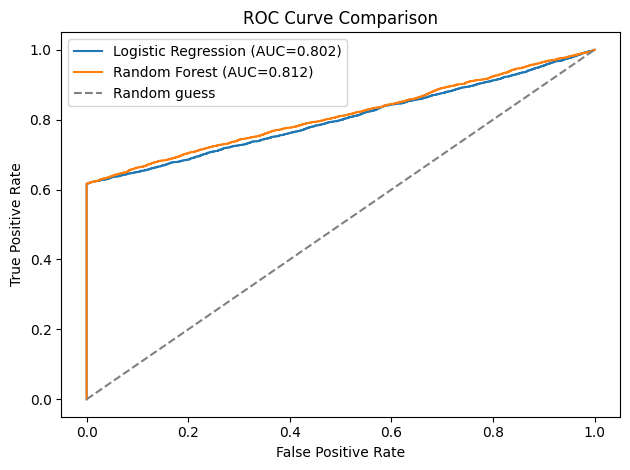

In [12]:
fig, ax = plt.subplots()
for name, y_prob in [('Logistic Regression', y_prob_lr), ('Random Forest', y_prob_rf)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/figures/10_roc_curve_comparison.png', dpi=120)
plt.show()

Random Forest has the higher ROC-AUC (0.812 vs 0.802) and notably perfect precision on the fraud
class - every fraud prediction it makes in the test set is correct. Its recall is lower (0.62),
meaning it misses more fraud cases than Logistic Regression, which catches more fraud overall
(0.72 recall) at the cost of more false alarms (0.56 precision).

Which model is "better" depends on the operational cost of a missed fraud case versus a false
alarm. If missing fraud is more costly, Logistic Regression's higher recall is more useful despite
lower precision. If false alarms are expensive (e.g. every flagged transaction needs manual
review), Random Forest's near-perfect precision means less wasted review time. This is a genuine
trade-off, not a clear winner either way.

## Feature Importance: Does The Model Agree With The Hypothesis Tests?

## Saving The Model

## Conclusions

---

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [ ]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)
